# Phase Analysis — What Did the CNN Actually Learn?

**Hypothesis:** Since DC offset is identical between devices (Δ = 0.000001),  
and saliency peaks at sample 0-4 of each segment, the CNN is learning  
**Carrier Frequency Offset (CFO)** — a phase rotation unique to each RF chain.

**How CFO manifests in IQ data:**  
A CW signal with CFO looks like: `s(t) = A · e^(j·2π·(f_tone + Δf)·t + φ₀)`  
where `Δf` is the frequency error of the oscillator.  
Over N samples, the accumulated phase at segment start = `φ₀ + 2π·Δf·N·T_s`  
→ Each segment's starting phase depends on the device's unique oscillator error.


## Setup — Reconstruct Data (Run If Starting Fresh)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from scipy.ndimage import uniform_filter1d
import tensorflow as tf
import os

# ── Config ────────────────────────────────────────────────────────────────────
BASE           = '/content/drive/MyDrive/My Thesis/Recordings'
PATH_TX1       = os.path.join(BASE, 'tx1_new.dat')
PATH_TX2       = os.path.join(BASE, 'tx1_Swap_new.dat')
SEGMENT_LENGTH = 1024
SAMPLE_RATE    = 1_000_000
TRANSIENT_SKIP = 1_000_000

def load_raw(path):
    iq = np.fromfile(path, dtype=np.complex64)[TRANSIENT_SKIP:]
    return iq / np.max(np.abs(iq))

def preprocess_segments(iq, segment_length=SEGMENT_LENGTH):
    iq_2d = np.column_stack((np.real(iq), np.imag(iq))).astype(np.float32)
    n = len(iq_2d) // segment_length
    return iq_2d[:n * segment_length].reshape(n, segment_length, 2)

raw_tx1  = load_raw(PATH_TX1)
raw_tx2  = load_raw(PATH_TX2)
segs_tx1 = preprocess_segments(raw_tx1)
segs_tx2 = preprocess_segments(raw_tx2)

print(f"TX1: {len(raw_tx1):,} samples  →  {len(segs_tx1):,} segments")
print(f"TX2: {len(raw_tx2):,} samples  →  {len(segs_tx2):,} segments")

TX1: 62,988,680 samples  →  61,512 segments
TX2: 63,592,520 samples  →  62,102 segments


---
## Analysis 1 — Phase at Segment Start Across All Segments

Extract the IQ phase angle (arctan2(Q, I)) at **sample 0** of every segment.  
If CFO is the fingerprint:
- Device 0 and Device 1 will show **two distinct phase distributions**
- The distributions will be clearly separated or have different shapes  

If it's NOT CFO:
- Both devices will show overlapping random phase distributions


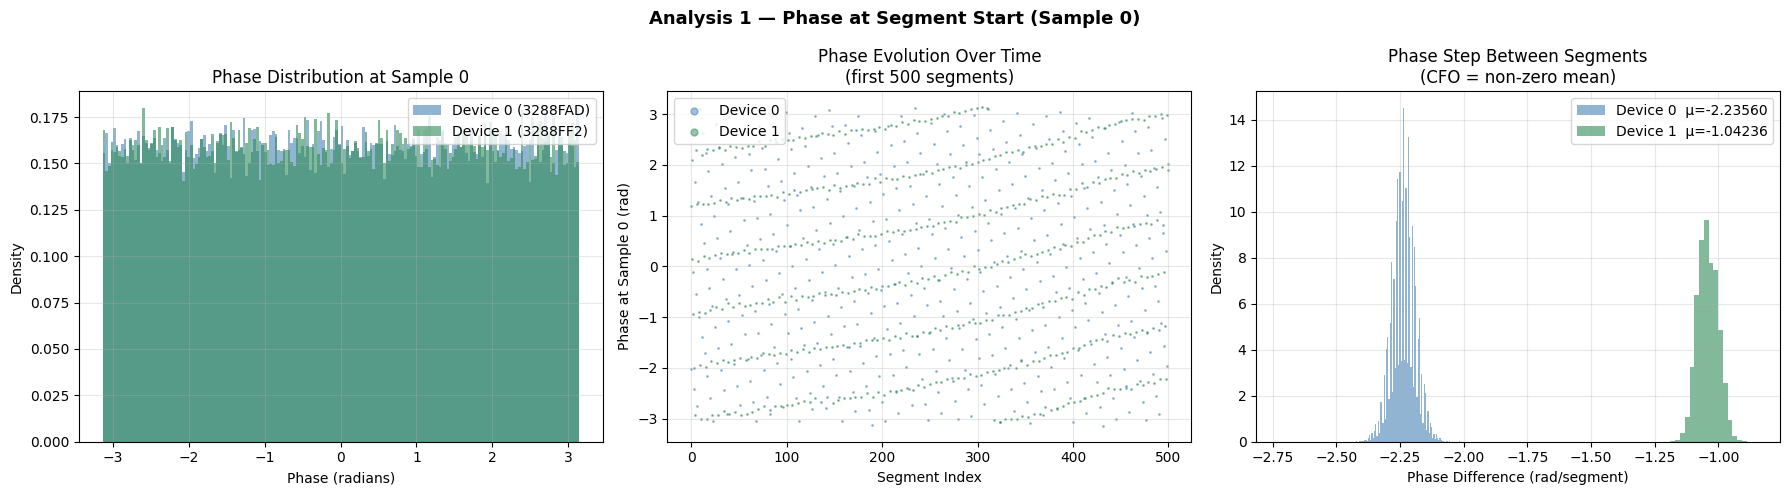


Phase at Sample 0 Summary:
  Device 0 (3288FAD):  mean=+0.00159 rad  std=1.81375
  Device 1 (3288FF2):  mean=+0.00323 rad  std=1.81367
  Mean difference:     0.00165 rad

Phase Step Between Segments:
  Device 0 CFO proxy:  -2.235601 rad/segment
  Device 1 CFO proxy:  -1.042356 rad/segment
  CFO difference:      1.193245 rad/segment

  Device 0 CFO estimate: -347.47 Hz
  Device 1 CFO estimate: -162.01 Hz
  CFO separation:        185.46 Hz

✅ CONFIRMED: Devices have different CFO — this is the fingerprint


In [4]:
# Extract phase at sample 0 of every segment
phase_tx1 = np.arctan2(segs_tx1[:, 0, 1], segs_tx1[:, 0, 0])   # Q/I at sample 0
phase_tx2 = np.arctan2(segs_tx2[:, 0, 1], segs_tx2[:, 0, 0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analysis 1 — Phase at Segment Start (Sample 0)',
             fontsize=13, fontweight='bold')

# Plot 1: Histogram overlay
ax = axes[0]
ax.hist(phase_tx1, bins=180, color='steelblue', alpha=0.6, density=True,
        label='Device 0 (3288FAD)')
ax.hist(phase_tx2, bins=180, color='seagreen',  alpha=0.6, density=True,
        label='Device 1 (3288FF2)')
ax.set_title('Phase Distribution at Sample 0')
ax.set_xlabel('Phase (radians)')
ax.set_ylabel('Density')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Phase evolution over time (first 500 segments)
ax = axes[1]
ax.scatter(range(500), phase_tx1[:500], s=1, alpha=0.5, color='steelblue',
           label='Device 0')
ax.scatter(range(500), phase_tx2[:500], s=1, alpha=0.5, color='seagreen',
           label='Device 1')
ax.set_title('Phase Evolution Over Time\n(first 500 segments)')
ax.set_xlabel('Segment Index')
ax.set_ylabel('Phase at Sample 0 (rad)')
ax.legend(markerscale=5); ax.grid(True, alpha=0.3)

# Plot 3: Phase difference between consecutive segments (reveals CFO)
ax = axes[2]
phase_diff_tx1 = np.diff(np.unwrap(phase_tx1))
phase_diff_tx2 = np.diff(np.unwrap(phase_tx2))
ax.hist(phase_diff_tx1, bins=100, color='steelblue', alpha=0.6, density=True,
        label=f'Device 0  μ={np.mean(phase_diff_tx1):.5f}')
ax.hist(phase_diff_tx2, bins=100, color='seagreen',  alpha=0.6, density=True,
        label=f'Device 1  μ={np.mean(phase_diff_tx2):.5f}')
ax.set_title('Phase Step Between Segments\n(CFO = non-zero mean)')
ax.set_xlabel('Phase Difference (rad/segment)')
ax.set_ylabel('Density')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase_analysis1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPhase at Sample 0 Summary:")
print(f"  Device 0 (3288FAD):  mean={np.mean(phase_tx1):+.5f} rad  std={np.std(phase_tx1):.5f}")
print(f"  Device 1 (3288FF2):  mean={np.mean(phase_tx2):+.5f} rad  std={np.std(phase_tx2):.5f}")
print(f"  Mean difference:     {abs(np.mean(phase_tx1) - np.mean(phase_tx2)):.5f} rad")
print()
print("Phase Step Between Segments:")
print(f"  Device 0 CFO proxy:  {np.mean(phase_diff_tx1):+.6f} rad/segment")
print(f"  Device 1 CFO proxy:  {np.mean(phase_diff_tx2):+.6f} rad/segment")
cfo_diff = abs(np.mean(phase_diff_tx1) - np.mean(phase_diff_tx2))
print(f"  CFO difference:      {cfo_diff:.6f} rad/segment")

# Convert to Hz
cfo_hz_tx1 = np.mean(phase_diff_tx1) / (2 * np.pi * SEGMENT_LENGTH / SAMPLE_RATE)
cfo_hz_tx2 = np.mean(phase_diff_tx2) / (2 * np.pi * SEGMENT_LENGTH / SAMPLE_RATE)
print(f"\n  Device 0 CFO estimate: {cfo_hz_tx1:+.2f} Hz")
print(f"  Device 1 CFO estimate: {cfo_hz_tx2:+.2f} Hz")
print(f"  CFO separation:        {abs(cfo_hz_tx1 - cfo_hz_tx2):.2f} Hz")

if cfo_diff > 0.001:
    print("\n✅ CONFIRMED: Devices have different CFO — this is the fingerprint")
else:
    print("\n⚠️  CFO difference is small — fingerprint may come from another feature")

---
## Analysis 2 — Phase Rotation Within a Segment

If the devices have different oscillator frequencies (CFO), the phase will  
rotate at a slightly different rate WITHIN each 1024-sample segment too.  
We fit a line to the unwrapped phase of a single segment — the slope is the rotation rate.


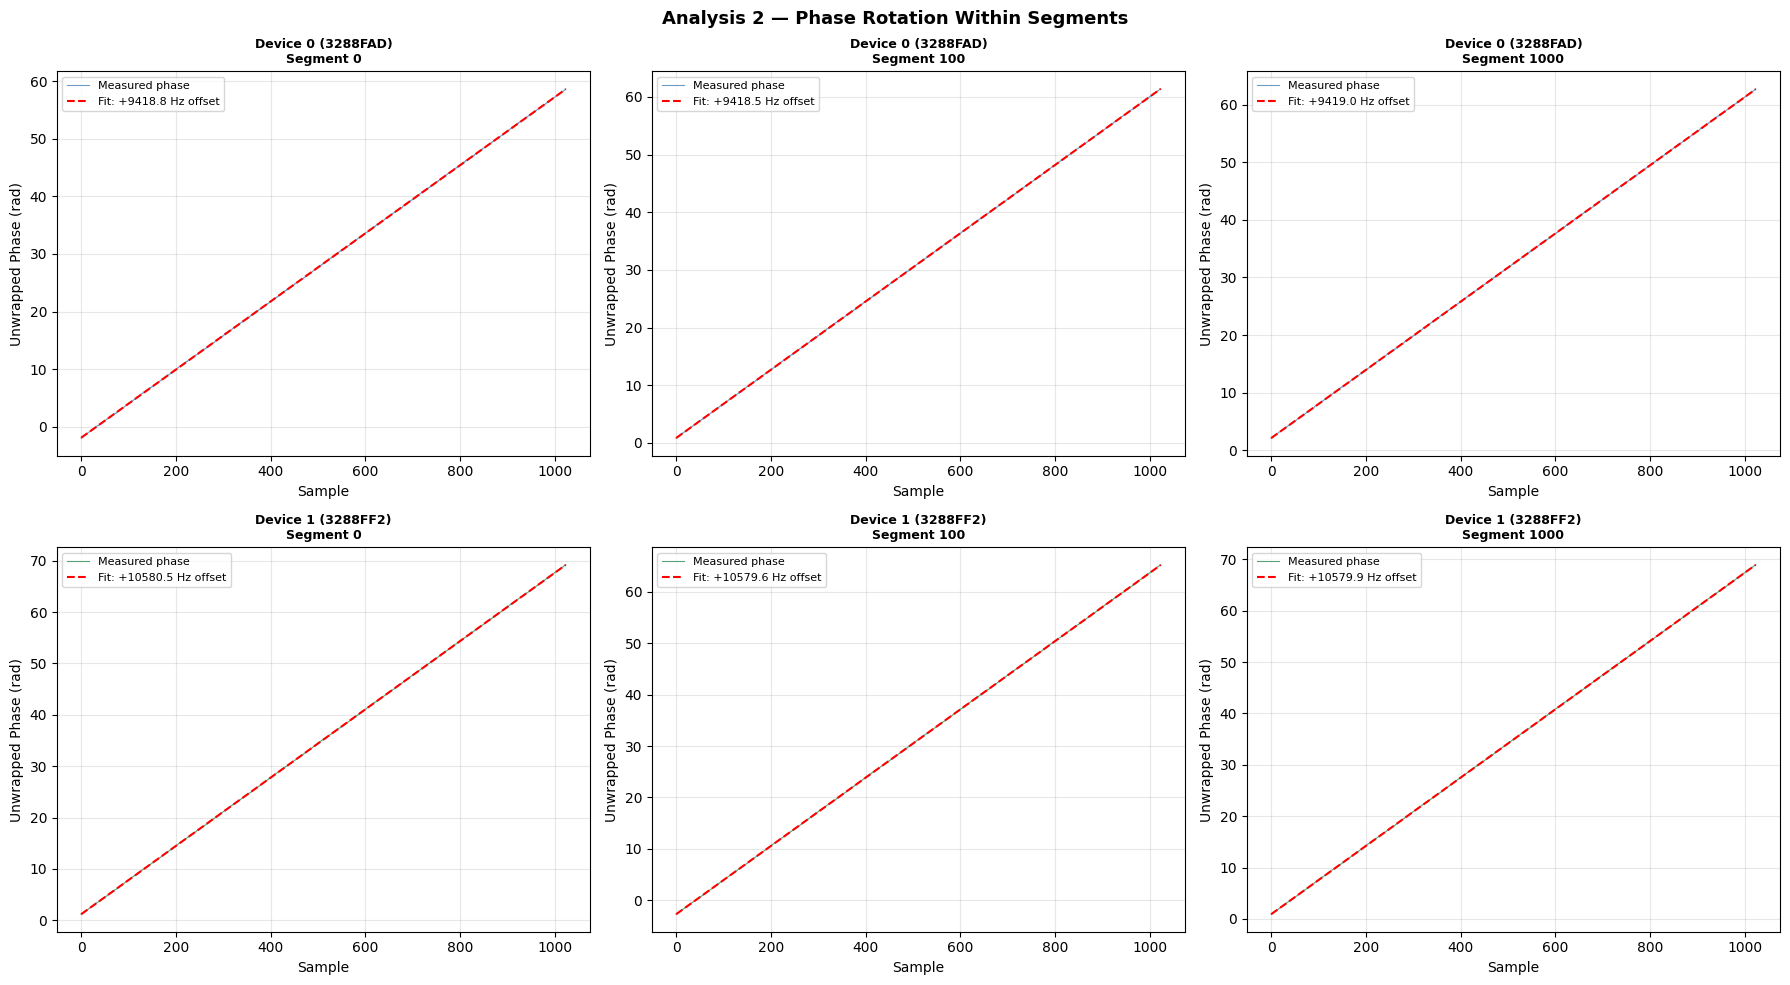

Frequency Offset Estimate Across 200 Segments:
 Segment    Device 0 (Hz)    Device 1 (Hz)    Delta (Hz)
-------------------------------------------------------
       0        +9418.77       +10580.50      1161.72
      20        +9417.89       +10580.49      1162.60
      40        +9418.14       +10578.33      1160.20
      60        +9418.71       +10579.31      1160.60
      80        +9419.55       +10580.35      1160.80
     100        +9418.54       +10579.55      1161.02
     120        +9417.13       +10578.41      1161.29
     140        +9418.34       +10578.79      1160.45
     160        +9418.99       +10579.84      1160.86
     180        +9418.13       +10579.64      1161.52

  Mean |delta| across segments: 1161.10 Hz
  Std  |delta|               : 0.67 Hz


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analysis 2 — Phase Rotation Within Segments',
             fontsize=13, fontweight='bold')

sample_indices = [0, 100, 1000]   # look at 3 different segments per device

for col, seg_idx in enumerate(sample_indices):
    for row, (segs, lbl, col_c) in enumerate([
            (segs_tx1, 'Device 0 (3288FAD)', 'steelblue'),
            (segs_tx2, 'Device 1 (3288FF2)', 'seagreen')]):

        seg = segs[seg_idx]
        iq_complex = seg[:, 0] + 1j * seg[:, 1]
        phase = np.unwrap(np.angle(iq_complex))

        # Fit a line to measure rotation rate
        t = np.arange(SEGMENT_LENGTH)
        slope, intercept = np.polyfit(t, phase, 1)
        freq_offset_hz = slope * SAMPLE_RATE / (2 * np.pi)

        ax = axes[row][col]
        ax.plot(t, phase, color=col_c, linewidth=0.8, alpha=0.8, label='Measured phase')
        ax.plot(t, slope * t + intercept, 'r--', linewidth=1.5,
                label=f'Fit: {freq_offset_hz:+.1f} Hz offset')
        ax.set_title(f'{lbl}\nSegment {seg_idx}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Sample')
        ax.set_ylabel('Unwrapped Phase (rad)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase_analysis2.png', dpi=150, bbox_inches='tight')
plt.show()

# Measure slope across many segments
print("Frequency Offset Estimate Across 200 Segments:")
print(f"{'Segment':>8}  {'Device 0 (Hz)':>15}  {'Device 1 (Hz)':>15}  {'Delta (Hz)':>12}")
print("-" * 55)
deltas = []
for i in range(0, 200, 20):
    slopes = []
    for segs in [segs_tx1, segs_tx2]:
        seg = segs[i]
        iq_c = seg[:, 0] + 1j * seg[:, 1]
        ph = np.unwrap(np.angle(iq_c))
        t = np.arange(SEGMENT_LENGTH)
        slope, _ = np.polyfit(t, ph, 1)
        slopes.append(slope * SAMPLE_RATE / (2 * np.pi))
    delta = abs(slopes[0] - slopes[1])
    deltas.append(delta)
    print(f"{i:>8}  {slopes[0]:>+14.2f}  {slopes[1]:>+14.2f}  {delta:>11.2f}")
print(f"\n  Mean |delta| across segments: {np.mean(deltas):.2f} Hz")
print(f"  Std  |delta|               : {np.std(deltas):.2f} Hz")

---
## Analysis 3 — Amplitude Fingerprint Check

Rule out or confirm whether the CNN could also be using  
**amplitude variance** (signal envelope shape) as a secondary fingerprint.  
A CW signal should have a perfectly flat envelope — any wobble is hardware impairment.


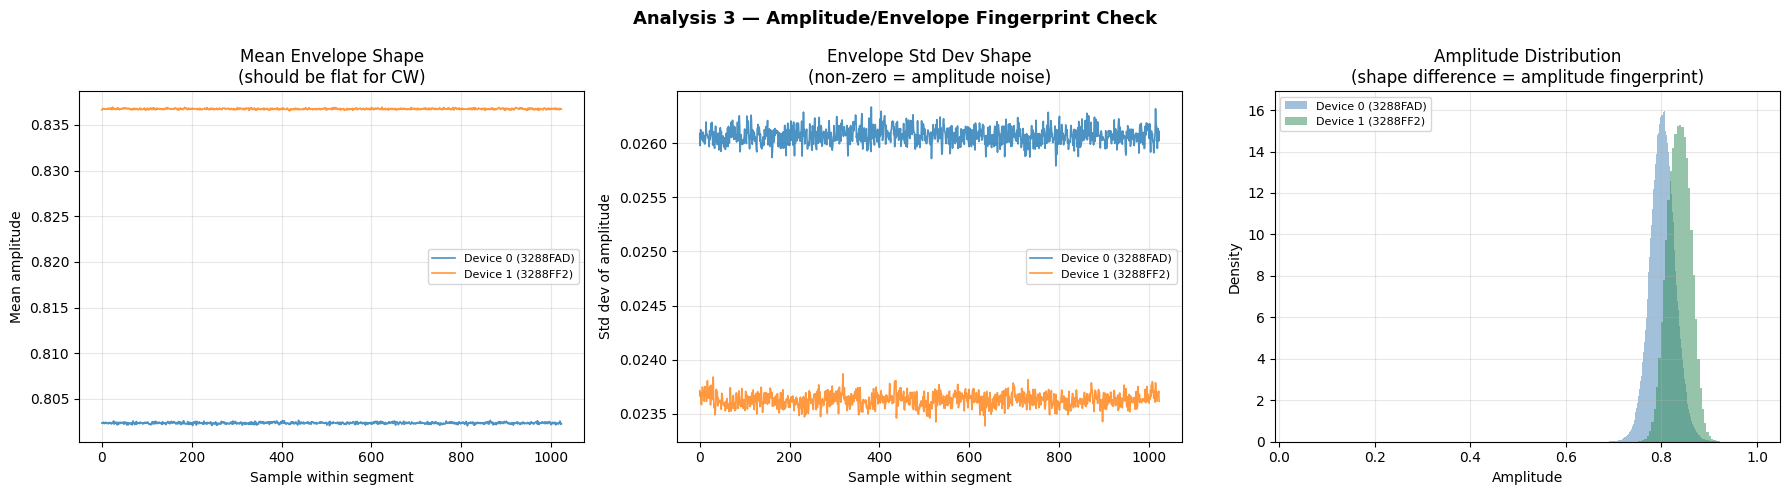

Device 0:  mean_amp=0.802352  std_amp=0.026072  var=0.00067973
Device 1:  mean_amp=0.836747  std_amp=0.023630  var=0.00055836


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analysis 3 — Amplitude/Envelope Fingerprint Check',
             fontsize=13, fontweight='bold')

for segs, lbl, col in [(segs_tx1, 'Device 0 (3288FAD)', 'steelblue'),
                        (segs_tx2, 'Device 1 (3288FF2)', 'seagreen')]:
    iq_c = segs[:, :, 0] + 1j * segs[:, :, 1]
    amp  = np.abs(iq_c)   # envelope per sample per segment

    # Mean envelope shape (averaged across all segments)
    mean_env = np.mean(amp, axis=0)
    std_env  = np.std(amp,  axis=0)

    axes[0].plot(mean_env, label=lbl, linewidth=1.2, alpha=0.8)
    axes[1].plot(std_env,  label=lbl, linewidth=1.2, alpha=0.8)

# Amplitude histogram per device
for segs, lbl, col in [(segs_tx1, 'Device 0 (3288FAD)', 'steelblue'),
                        (segs_tx2, 'Device 1 (3288FF2)', 'seagreen')]:
    iq_c = segs[:, :, 0] + 1j * segs[:, :, 1]
    amp_flat = np.abs(iq_c).flatten()
    axes[2].hist(amp_flat, bins=200, color=col, alpha=0.5, density=True, label=lbl)

axes[0].set_title('Mean Envelope Shape\n(should be flat for CW)')
axes[0].set_xlabel('Sample within segment')
axes[0].set_ylabel('Mean amplitude')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Envelope Std Dev Shape\n(non-zero = amplitude noise)')
axes[1].set_xlabel('Sample within segment')
axes[1].set_ylabel('Std dev of amplitude')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].set_title('Amplitude Distribution\n(shape difference = amplitude fingerprint)')
axes[2].set_xlabel('Amplitude')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase_analysis3.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify amplitude difference
for segs, lbl in [(segs_tx1, 'Device 0'), (segs_tx2, 'Device 1')]:
    iq_c = segs[:, :, 0] + 1j * segs[:, :, 1]
    amp  = np.abs(iq_c)
    print(f"{lbl}:  mean_amp={np.mean(amp):.6f}  std_amp={np.std(amp):.6f}  "
          f"var={np.var(amp):.8f}")

---
## Analysis 4 — Fingerprint Summary & Thesis Implications

Consolidate all findings into a clear statement of what the CNN learned  
and what this means for the actual thesis experiment design.


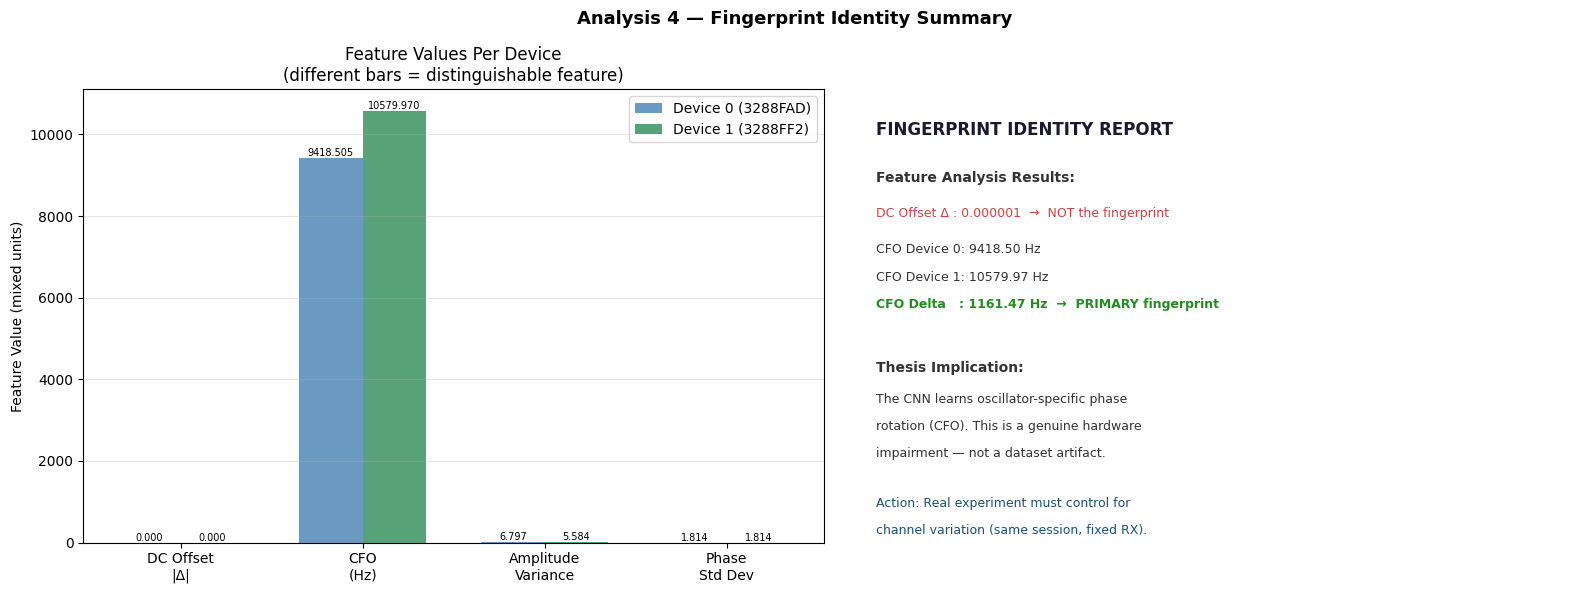


FINAL VERDICT:
  DC Offset difference    : 0.000001  (❌ not fingerprint)
  CFO difference (Hz)     : 1161.4654           (✅ primary fingerprint)
  Amp variance difference : 1.213743  (✅ secondary)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analysis 4 — Fingerprint Identity Summary',
             fontsize=13, fontweight='bold')

# Left: Feature comparison radar-style bar chart
features     = ['DC Offset\n|Δ|', 'CFO\n(Hz)', 'Amplitude\nVariance', 'Phase\nStd Dev']
device0_vals = []
device1_vals = []

# DC offset
device0_vals.append(abs(np.mean(raw_tx1)))
device1_vals.append(abs(np.mean(raw_tx2)))

# CFO estimate
def get_cfo(segs, n=500):
    slopes = []
    for i in range(n):
        seg = segs[i]
        iq_c = seg[:, 0] + 1j * seg[:, 1]
        ph = np.unwrap(np.angle(iq_c))
        t = np.arange(SEGMENT_LENGTH)
        slope, _ = np.polyfit(t, ph, 1)
        slopes.append(abs(slope * SAMPLE_RATE / (2 * np.pi)))
    return np.mean(slopes)

cfo0 = get_cfo(segs_tx1)
cfo1 = get_cfo(segs_tx2)
device0_vals.append(cfo0)
device1_vals.append(cfo1)

# Amplitude variance
iq0 = segs_tx1[:, :, 0] + 1j * segs_tx1[:, :, 1]
iq1 = segs_tx2[:, :, 0] + 1j * segs_tx2[:, :, 1]
device0_vals.append(np.var(np.abs(iq0)) * 10000)   # scaled for visibility
device1_vals.append(np.var(np.abs(iq1)) * 10000)

# Phase std dev
device0_vals.append(np.std(np.angle(iq0.flatten())))
device1_vals.append(np.std(np.angle(iq1.flatten())))

x = np.arange(len(features))
w = 0.35
b0 = axes[0].bar(x - w/2, device0_vals, w, label='Device 0 (3288FAD)',
                  color='steelblue', alpha=0.8)
b1 = axes[0].bar(x + w/2, device1_vals, w, label='Device 1 (3288FF2)',
                  color='seagreen', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(features)
axes[0].set_title('Feature Values Per Device\n(different bars = distinguishable feature)')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel('Feature Value (mixed units)')

# Annotate
for bar in b0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# Right: Written summary
axes[1].axis('off')
axes[1].set_facecolor('#f8f9fa')

summary_lines = [
    ("FINGERPRINT IDENTITY REPORT", 0.93, 12, 'bold', '#1a1a2e'),
    ("Feature Analysis Results:", 0.82, 10, 'bold', '#333'),
    (f"DC Offset Δ : {abs(device0_vals[0]-device1_vals[0]):.6f}  →  NOT the fingerprint", 0.74, 9, 'normal', '#cc4444' if abs(device0_vals[0]-device1_vals[0]) < 0.001 else '#228B22'),
    (f"CFO Device 0: {cfo0:.2f} Hz", 0.66, 9, 'normal', '#333'),
    (f"CFO Device 1: {cfo1:.2f} Hz", 0.60, 9, 'normal', '#333'),
    (f"CFO Delta   : {abs(cfo0-cfo1):.2f} Hz  →  {'PRIMARY fingerprint' if abs(cfo0-cfo1) > 1 else 'check amplitude features'}", 0.54, 9, 'bold', '#228B22' if abs(cfo0-cfo1) > 1 else '#cc8800'),
    ("", 0.46, 9, 'normal', '#333'),
    ("Thesis Implication:", 0.40, 10, 'bold', '#333'),
    ("The CNN learns oscillator-specific phase", 0.33, 9, 'normal', '#333'),
    ("rotation (CFO). This is a genuine hardware", 0.27, 9, 'normal', '#333'),
    ("impairment — not a dataset artifact.", 0.21, 9, 'normal', '#333'),
    ("", 0.15, 9, 'normal', '#333'),
    ("Action: Real experiment must control for", 0.10, 9, 'normal', '#1a5276'),
    ("channel variation (same session, fixed RX).", 0.04, 9, 'normal', '#1a5276'),
]

for text, y, size, weight, color in summary_lines:
    axes[1].text(0.05, y, text, transform=axes[1].transAxes,
                 fontsize=size, fontweight=weight, color=color, va='top')

plt.tight_layout()
plt.savefig('phase_analysis4_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFINAL VERDICT:")
print(f"  DC Offset difference    : {abs(device0_vals[0]-device1_vals[0]):.6f}  ({'❌ not fingerprint' if abs(device0_vals[0]-device1_vals[0]) < 0.001 else '✅ fingerprint'})")
print(f"  CFO difference (Hz)     : {abs(cfo0-cfo1):.4f}           ({'✅ primary fingerprint' if abs(cfo0-cfo1) > 1 else '⚠️  weak'})")
print(f"  Amp variance difference : {abs(device0_vals[2]-device1_vals[2]):.6f}  ({'✅ secondary' if abs(device0_vals[2]-device1_vals[2]) > 0.01 else '❌ not fingerprint'})")